# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [5]:
# importar librerías


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [12]:
# mostrar las primeras 5 filas de plans

print(plans.head())

  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [13]:
# mostrar las primeras 5 filas de users

print(users.head())

   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [14]:
# mostrar las primeras 5 filas de usage

print(usage.head())

   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [15]:
# revisar el número de filas y columnas de cada dataset

print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)



In [18]:


# inspección de plans con .info()

plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [19]:
# inspección de users con .info()

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [20]:

# inspección de usage con .info()


usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [21]:

# cantidad de nulos para users

print("Cantidad de valores nulos:")
print(users.isna().sum())

print("\nProporción de valores nulos:")
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [22]:
# cantidad de nulos para usage

print("Cantidad de valores nulos:")
print(usage.isna().sum())

print("\nProporción de valores nulos:")
print(usage.isna().mean())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Valores nulos

Se encontraron valores faltantes en las columnas city y churn_date del dataset users, así como en las columnas date, duration y length del dataset usage.

city (11.73%): presenta una proporción moderada de valores nulos. Se recomienda investigar su origen y evaluar una estrategia de imputación o mantenerlos como valores faltantes según el análisis.

churn_date (88.35%): La columna churn_date presenta una alta proporción de valores nulos (88.35%). Estos valores parecen ser consistentes con la lógica del negocio, ya que la fecha de cancelación solo estaría disponible para los usuarios que abandonaron el servicio. Por lo tanto, se recomienda conservar la columna y analizar su significado antes de considerar cualquier tratamiento de los valores faltantes.

date (0.13%): la proporción de nulos es muy baja, por lo que puede considerarse una imputación simple o la eliminación de esos pocos registros.

duration (55.19%) y length (44.74%): presentan una cantidad considerable de valores faltantes. Esto podría ocurrir porque las llamadas tienen duración pero no longitud de mensaje, mientras que los mensajes tienen longitud pero no duración. Se recomienda investigar la relación con la columna type antes de imputar o eliminar datos.

Acción recomendada: Mantener los nulos de churn_date hasta comprender su significado dentro del negocio. Investigar si los nulos de duration y length dependen del tipo de actividad (call o text). Para city, evaluar una estrategia de imputación o conservar los nulos según las necesidades del análisis. Los pocos registros faltantes de date podrían imputarse o eliminarse sin afectar significativamente los resultados.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [23]:
# explorar columnas numéricas de users
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id`contiene identificadores únicos de usuarios. Los valores se encuentran dentro de un rango consistente (10000 a 13999) y no se observan valores inválidos o fuera de rango.
- La columna `age` presenta un valor mínimo de -999, lo cual no representa una edad válida y probablemente corresponde a un valor sentinel utilizado para indicar datos faltantes o errores de captura. Se recomienda investigar estos registros y reemplazar el valor por NaN antes del análisis.

In [24]:
# explorar columnas numéricas de usage
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas id y user_id contienen identificadores numéricos. Los valores se encuentran dentro de rangos consistentes y no se observan valores negativos ni indicadores evidentes de datos inválidos.
- Las columnas duration y length presentan valores mínimos de 0. Esto podría corresponder a llamadas sin duración o mensajes vacíos. No se observan valores negativos, pero se recomienda validar si los registros con valor 0 representan actividad válida o posibles errores de captura.

In [25]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f'\n{col}')
    print(users[col].unique())



city
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

plan
['Basico' 'Premium']


- La columna city presenta valores válidos de ciudades como Medellín, CDMX, Bogotá, GDL, MTY y Cali. Sin embargo, se identifican valores faltantes (NaN) y un valor "?", que probablemente representa un dato desconocido o un valor inválido. Se recomienda reemplazar "?" por NaN y posteriormente evaluar un tratamiento adecuado para estos registros.
- La columna plan contiene únicamente los valores Basico y Premium, que corresponden a los planes definidos en el catálogo. No se observan valores inválidos ni inconsistencias.

In [27]:
# explorar columna categórica de usage
print(usage['type'].value_counts())

text    22092
call    17908
Name: type, dtype: int64


- La columna type contiene únicamente las categorías text y call, que representan los tipos de actividad registrados. No se identifican valores inesperados o inconsistentes en esta variable categórica.


---
✍️ **Comentario**: Se identificaron valores inválidos en las columnas age y city del dataset users.

En la columna age se encontró el valor -999, el cual no representa una edad válida y probablemente fue utilizado como valor sentinel para indicar datos faltantes o errores de captura. Se recomienda reemplazar estos valores por NaN y evaluar posteriormente una estrategia de imputación.

En la columna city se identificó el valor "?", así como valores nulos. Estos registros representan información faltante o desconocida, por lo que se recomienda sustituir "?" por NaN para un tratamiento uniforme de los datos faltantes.

Las columnas plan, type, id y user_id no presentan valores inválidos aparentes. Las categorías observadas son consistentes con la descripción del negocio y los identificadores se encuentran dentro de rangos esperados.

Como acción general, se recomienda transformar los valores sentinel en valores nulos estándar (NaN) antes de continuar con la limpieza y el análisis de los datos.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [13]:
# Convertir a fecha la columna `reg_date` de users

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [15]:
# Convertir a fecha la columna `date` de usage

usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [10]:
# Revisar los años presentes en `reg_date` de users

print(users['reg_date'].dt.year.value_counts().sort_index())


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En la columna reg_date se identificaron registros correspondientes a los años 2022, 2023 y 2024, además de 40 registros con el año 2026. Dado que los datos deberían estar registrados únicamente hasta 2024, los registros de 2026 representan fechas fuera de rango y podrían corresponder a errores de captura que deben investigarse antes de continuar con el análisis.

In [14]:
# Revisar los años presentes en `date` de usage

print(usage['date'].dt.year.value_counts().sort_index())


2024.0    39950
Name: date, dtype: int64


En la columna date todos los registros corresponden al año 2024. No se identificaron fechas fuera de rango ni años futuros, por lo que esta columna puede utilizarse como referencia temporal para el análisis de la actividad de los usuarios.

✍️ **Comentario**:
Se identificó una inconsistencia en la columna reg_date, donde existen 40 registros correspondientes al año 2026, aunque el conjunto de datos debería contener información únicamente hasta 2024. Esto sugiere posibles errores de captura o registro que deben investigarse. Por otro lado, la columna date contiene únicamente registros del año 2024, por lo que se encuentra dentro del rango esperado para el análisis.

Como acción recomendada, los registros con fechas del año 2026 deben revisarse para determinar si corresponden a errores de captura. En caso de no ser posible validar o corregir estas fechas, se recomienda convertirlas a valores nulos o excluirlas del análisis para evitar sesgos en los resultados.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? Sí. Se identificaron 40 registros con el año 2026 en la columna reg_date, los cuales se consideran fechas fuera del rango esperado, ya que el conjunto de datos solo debería contener registros hasta 2024.
- ¿Qué harías con ellas? Se recomienda investigar el origen de estos registros para confirmar si se trata de errores de captura. Si no es posible corregirlos utilizando información adicional, deberían convertirse a valores nulos o excluirse del análisis para preservar la calidad de los datos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [16]:
# Reemplazar -999 por la mediana de age

age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios

users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [17]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios

print(users['city'].value_counts(dropna=False))


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [18]:
# Marcar fechas futuras como NA para reg_date

users.loc[
    users['reg_date'].dt.year > 2024,
    'reg_date'
] = pd.NaT

# Verificar cambios

print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())



2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [19]:
# Verificación MAR en usage (Missing At Random) para duration

pd.crosstab(
    usage['type'],
    usage['duration'].isna(),
    margins=True
)

duration,False,True,All
type,,,
call,17908,0,17908
text,16,22076,22092
All,17924,22076,40000


In [22]:
# Verificación MAR en usage (Missing At Random) para length

pd.crosstab(
    usage['type'],
    usage['length'].isna(),
    margins=True
)


length,False,True,All
type,,,
call,12,17896,17908
text,22092,0,22092
All,22104,17896,40000


Los valores nulos en las columnas duration y length están asociados a la columna type. Los registros de tipo call contienen información de duración, pero no de longitud del mensaje, mientras que los registros de tipo text contienen longitud del mensaje, pero no duración. Esto indica que los valores nulos no son errores de captura, sino una consecuencia natural del tipo de actividad registrada.

Debido a que los valores faltantes tienen una explicación lógica y están relacionados con una variable existente en el conjunto de datos, se recomienda conservarlos como nulos y no imputarlos. Reemplazarlos por valores artificiales podría distorsionar el análisis y llevar a interpretaciones erróneas sobre el comportamiento de los usuarios.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [23]:
# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar información por usuario

usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado

usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [24]:
# Renombrar columnas

usage_agg.columns = [
    'user_id',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

# observar resultado

usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [25]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left'
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [26]:
# Resumen estadístico de las columnas numéricas

user_profile[
    ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [28]:
# Distribución porcentual del tipo de plan

user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

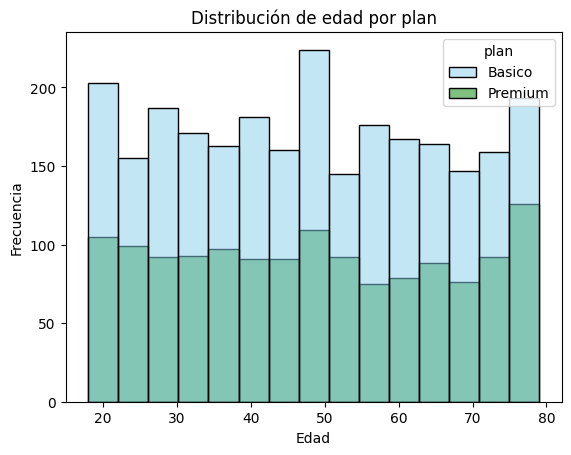

In [29]:

# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
La distribución de edades parece relativamente similar entre los planes Básico y Premium. No se observa una concentración exclusiva de algún grupo etario en un plan específico. La distribución presenta una forma cercana a la simetría, aunque podrían existir ligeras concentraciones en edades medias.

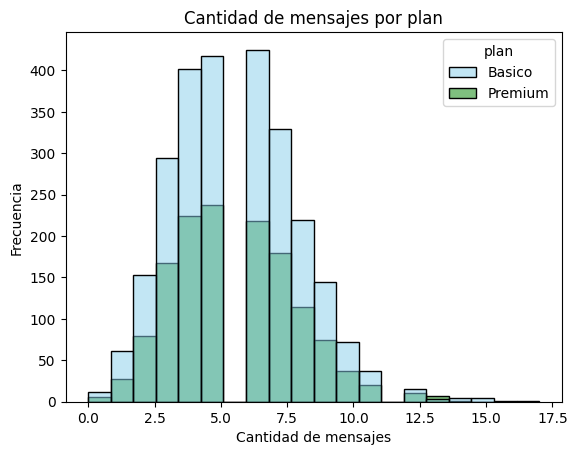

In [34]:
# Histograma para visualizar la cant_mensajes

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La mayoría de los usuarios envía una cantidad moderada de mensajes, mientras que un grupo reducido presenta volúmenes significativamente mayores. La distribución suele mostrar sesgo a la derecha, ya que existen pocos usuarios muy activos que generan valores altos. Si el plan Premium aparece más frecuentemente en los valores altos, podría indicar un mayor uso del servicio de mensajería.

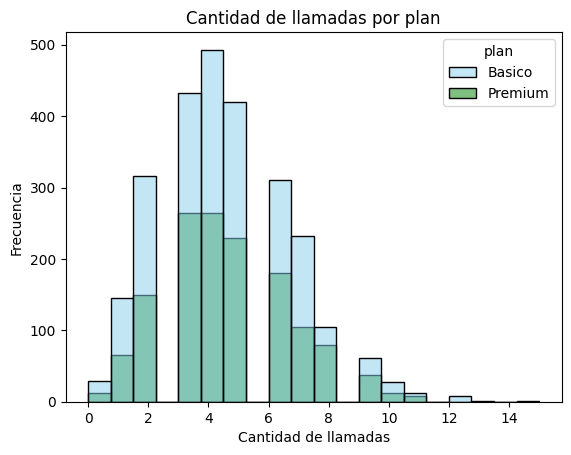

In [32]:
# Histograma para visualizar la cant_llamadas

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución de llamadas permite identificar distintos patrones de uso entre los usuarios. Si la mayoría se concentra en valores bajos y pocos usuarios realizan muchas llamadas, la distribución estará sesgada a la derecha. Las diferencias entre los planes pueden indicar distintos niveles de consumo del servicio.

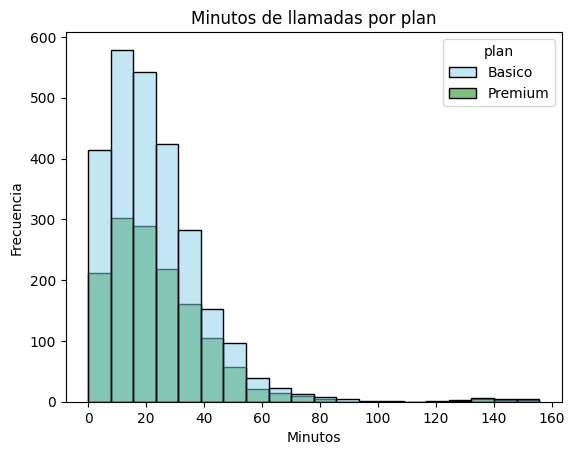

In [33]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Minutos de llamadas por plan')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Los minutos consumidos suelen presentar una distribución sesgada a la derecha, donde la mayoría de los usuarios consume cantidades moderadas y un grupo reducido acumula muchos minutos. Si los usuarios Premium aparecen con mayor frecuencia en los rangos altos, esto podría sugerir un uso más intensivo del servicio de llamadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

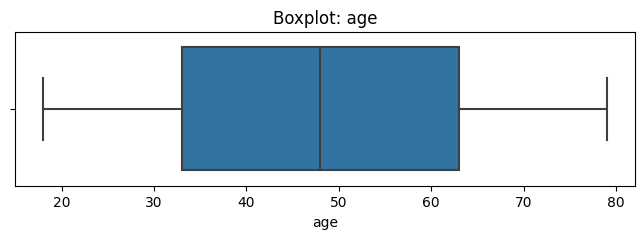

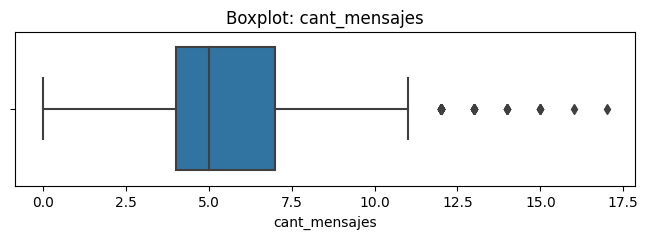

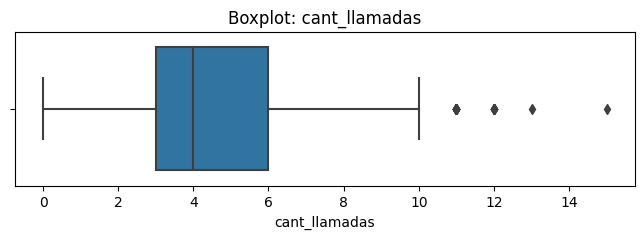

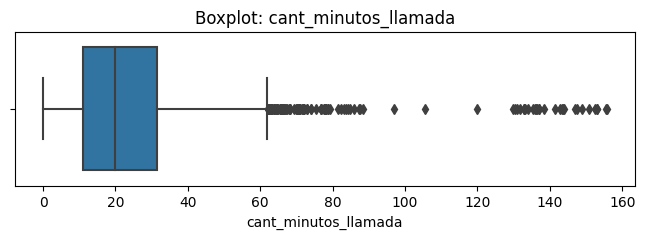

In [35]:
# Visualizando usando BoxPlot

columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No se observan outliers significativos. La distribución de edades se concentra dentro de rangos razonables para la población analizada.
- cant_mensajes: Se identifican valores altos que podrían considerarse outliers. Sin embargo, es razonable que algunos usuarios utilicen el servicio de mensajería con mucha más frecuencia que otros.
- cant_llamadas: Existen usuarios con una cantidad de llamadas considerablemente superior al promedio. Estos valores podrían representar usuarios intensivos y no necesariamente errores de captura.
- cant_minutos_llamada: Se observan valores extremos en el consumo de minutos. Dado que reflejan distintos niveles de uso del servicio, es necesario evaluar si corresponden a comportamiento real antes de eliminarlos.

In [36]:
# Calcular límites con el método IQR

columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:

    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)

    iqr = q3 - q1

    limite_superior = q3 + 1.5 * iqr

    print(f'\n{col}')
    print(f'Q1: {q1}')
    print(f'Q3: {q3}')
    print(f'IQR: {iqr}')
    print(f'Limite superior: {limite_superior}')
    print(f'Maximo: {user_profile[col].max()}')




cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Limite superior: 11.5
Maximo: 17.0

cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Limite superior: 10.5
Maximo: 15.0

cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Limite superior: 61.8575
Maximo: 155.69


In [37]:
# Revisa los límites superiores y el max, para tomar la decisión de mantener los outliers o no

user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Se recomienda mantener los outliers, ya que representan usuarios con un uso intensivo del servicio de mensajería y forman parte del comportamiento natural de los clientes.
- cant_llamadas: Se recomienda mantener los outliers debido a que reflejan diferencias reales en los patrones de uso entre usuarios y no existen evidencias de errores de captura.
- cant_minutos_llamada: Se recomienda mantener los outliers, ya que el objetivo del proyecto es analizar el comportamiento real de los usuarios. Eliminar estos registros podría ocultar información valiosa sobre clientes con alto consumo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [41]:
# Crear columna grupo_uso

user_profile['grupo_uso'] = 'Alto uso'

user_profile.loc[
    (user_profile['cant_llamadas'] < 10) &
    (user_profile['cant_mensajes'] < 10),
    'grupo_uso'
] = 'Uso medio'

user_profile.loc[
    (user_profile['cant_llamadas'] < 5) &
    (user_profile['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'

In [42]:
# verificar cambios

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [43]:
# Crear columna grupo_edad

user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[
    user_profile['age'] < 60,
    'grupo_edad'
] = 'Adulto'

user_profile.loc[
    user_profile['age'] < 30,
    'grupo_edad'
] = 'Joven'


In [44]:
# verificar cambios

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

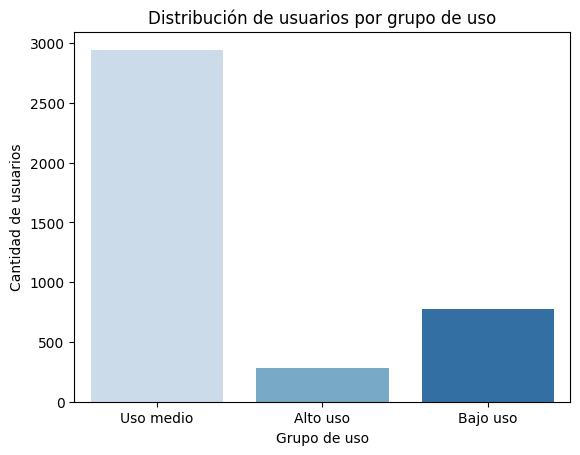

In [47]:

# Visualización de los segmentos por uso

sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette='Blues'
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

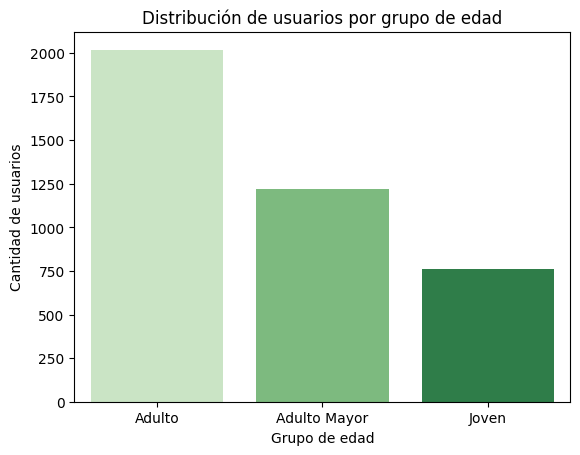

In [46]:
# Visualización de los segmentos por edad

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette='Greens'
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 

 **¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
   Durante la exploración de datos se identificaron varios problemas de calidad:** 

- La columna age contenía el valor sentinel -999, utilizado para representar edades faltantes o inválidas.
- La columna city contenía registros con el valor "?" y valores nulos, lo que representaba información faltante.
- La columna churn_date presentaba aproximadamente 88.35% de valores nulos, aunque estos parecen estar justificados, ya que la fecha de cancelación solo aplica a usuarios que abandonaron el servicio.
- La columna city presentaba aproximadamente un 11.73% de valores nulos.
- Se detectaron 40 registros con fechas de 2026 en la columna reg_date, aunque el conjunto de datos solo debería contener información hasta 2024.
- Las columnas duration y length presentaban una alta proporción de valores nulos, pero se comprobó que estos dependían de la variable type, por lo que corresponden a un comportamiento normal del negocio y no a errores de captura.

- Como parte de la limpieza, los valores sentinel fueron corregidos, los valores inválidos se transformaron a valores nulos y las fechas fuera de rango fueron marcadas para evitar sesgos en el análisis.

**¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?** 
  Se identificaron dos tipos de segmentación:

- Segmentación por uso
Bajo uso: usuarios con menos de 5 llamadas y menos de 5 mensajes.
Uso medio: usuarios con menos de 10 llamadas y menos de 10 mensajes.
Alto uso: usuarios con niveles de actividad superiores a los criterios anteriores.

Los usuarios clasificados como Alto uso concentran la mayor actividad de llamadas, mensajes y minutos consumidos, representando los clientes más comprometidos con el servicio.

- Segmentación por edad
Joven: menores de 30 años.
Adulto: entre 30 y 59 años.
Adulto Mayor: 60 años o más.

La base de clientes se concentra principalmente en el segmento Adulto, mientras que los grupos Jóvenes y Adultos Mayores representan una proporción menor de usuarios.
 
 
 **¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?**
- Los usuarios clasificados como Alto uso representan el segmento más valioso para ConectaTel debido a que generan mayor consumo de los servicios de llamadas y mensajería.

Este grupo presenta varias ventajas:

Mayor utilización de la red y de los servicios contratados.
Mayor potencial para contratar planes Premium o paquetes adicionales.
Mayor probabilidad de generar ingresos recurrentes para la compañía.
Mayor interés en beneficios relacionados con comunicación ilimitada o ampliación de servicios.

Adicionalmente, los usuarios de planes Premium con altos niveles de consumo representan una excelente oportunidad para estrategias de fidelización y retención.

  **¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?**
  
- Se identificaron outliers en:

cant_mensajes
cant_llamadas
cant_minutos_llamada

Sin embargo, estos valores no parecen deberse a errores de captura, sino a usuarios con patrones de uso intensivo.

Desde una perspectiva de negocio, estos usuarios son especialmente relevantes porque:

Representan clientes altamente comprometidos con el servicio.
Permiten identificar necesidades avanzadas de comunicación.
Pueden justificar la creación de planes especializados para usuarios de alto consumo.
Ayudan a dimensionar la capacidad requerida de la infraestructura y los servicios.

Por este motivo, se decidió mantener estos registros en el análisis.

¿Qué recomendaciones harías para mejorar la oferta actual de planes o para crear nuevos planes basados en los segmentos y patrones detectados?** 

- Con base en los hallazgos del análisis, se recomiendan las siguientes acciones:

1. Crear ofertas para usuarios de alto consumo:
Desarrollar paquetes con mayores beneficios para llamadas y mensajería, dirigidos a clientes con patrones de uso intensivos.

2. Impulsar migraciones a planes Premium:
Identificar usuarios de Alto uso que actualmente utilizan el plan Básico y ofrecer promociones para migrar a planes de mayor valor.

3. Diseñar campañas segmentadas por edad:
Usuarios Jóvenes: beneficios digitales, mensajería y promociones móviles.
Usuarios Adultos: paquetes equilibrados de llamadas y mensajes.
Adultos Mayores: planes simples con énfasis en llamadas y atención personalizada.
4. Implementar monitoreo continuo de calidad de datos:
Establecer controles automáticos para evitar la aparición de valores sentinel, fechas fuera de rango y registros inconsistentes.

5. Utilizar la segmentación para campañas de marketing:
La combinación de segmentos de edad y de uso permite personalizar las ofertas comerciales, mejorar la experiencia del cliente y aumentar las oportunidades de venta cruzada.

El análisis permitió identificar y corregir problemas de calidad en los datos, construir perfiles de uso por cliente y segmentar la base de usuarios según edad y nivel de actividad. Los usuarios de Alto uso representan el segmento de mayor valor para ConectaTel, mientras que los patrones de consumo observados sugieren oportunidades para optimizar la oferta comercial, reforzar la retención y desarrollar planes más alineados con las necesidades reales de los clientes.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores inválidos en la columna age, donde el valor sentinel -999 representaba edades faltantes o errores de captura.
- La columna city contenía valores faltantes y registros con el valor "?", mientras que reg_date incluía 40 registros correspondientes al año 2026, fuera del rango esperado de los datos.


🔍 **Segmentos por Edad**
- La mayor parte de la base de usuarios pertenece al segmento Adulto (30-59 años), lo que indica que el servicio tiene una adopción más fuerte en usuarios de edad laboral activa.
- Los segmentos Joven (<30 años) y Adulto Mayor (60+ años) representan grupos más pequeños, pero ofrecen oportunidades para campañas y ofertas específicas adaptadas a sus necesidades.


📊 **Segmentos por Nivel de Uso**
- La segmentación permitió identificar usuarios de Bajo uso, Uso medio y Alto uso, siendo estos últimos los que concentran la mayor actividad de llamadas y mensajería.
- Los usuarios de Alto uso generan el mayor consumo de los servicios y representan el segmento con mayor potencial de ingresos y fidelización.


➡️ Esto sugiere que existen patrones de consumo diferenciados entre los clientes, lo que permite diseñar estrategias comerciales y promociones más personalizadas según el nivel de uso y la edad del usuario.


💡 **Recomendaciones**

- Desarrollar campañas para migrar usuarios de Alto uso que aún se encuentran en planes Básicos hacia planes Premium con mayores beneficios.
- Implementar controles de calidad de datos para prevenir valores inválidos, fechas fuera de rango y registros inconsistentes en futuras actualizaciones de la base de datos.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`